In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quark.app import Recipe, s  # (1)!

In [16]:
s.login('baqis') # 登录 (1)

# s.signup('baqis','sample_config')

s.start() # 打开设备 (3)

2025-07-10 12:23:15.296 | INFO     | quark.app:login:171 - LOGINED[baqis], Checkpoint[2025-07-10 12:22:55 Thu] loaded from: /Users/hqubit/QCLab_hqubit/home/cfg/sample_config.ckpt


[2025-07-10 12:23:15.222][QuarkServer][CRITICAL💀] @SEND: NoneType[Errno 54] Connection reset by peer


'QuarkServer started!'

In [19]:
def S21(qubits: tuple[str], freq:float, ctx=None) -> list: # 
    """qlisp线路函数。ctx为编译所需上下文，主要用于对cfg表进行查询等操作。
    """
    cc = [(('Measure', i, ), q) for i, q in enumerate(qubits)]
    return cc

rcp = Recipe('s21', signal='iq_avg') # 任务定义
rcp.circuit = S21 # 线路指定 (1)

qubits = tuple(['Q0', 'Q4', 'Q9'])
rcp['qubits'] = qubits
rcp['freq'] = np.linspace(-5, 5, 101) * 1e6 # (2)

for q in qubits: # 参数设置 (3)
    rcp[f'gate.Measure.{q}.params.frequency'] = rcp['freq'] + \
        s.query(f'gate.Measure.{q}.params.frequency') # 变量关联
    rcp[f'gate.Measure.{q}.default_type'] = 'default' # 临时设置

In [21]:
s21 = s.submit(rcp.export(), block=False, preview=['M1'], plot=True) # (1)
s21.bar(interval=1)  # (2)

baqis:/s21   0%|          |0/101 [00:00<?, ?it/s, MainThread]

[2025-07-10 12:27:01.186][QuarkViewer][CRITICAL💀] @SEND: NoneType[Errno 54] Connection reset by peer


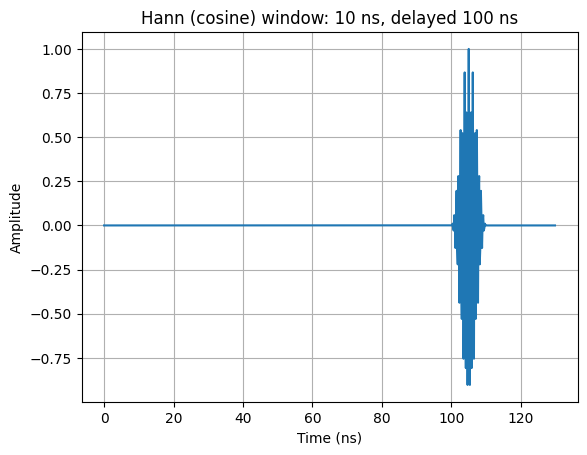

In [14]:
# 余弦窗（Hann window）长度10 ns，幅值1，整体延时100 ns，并绘制
from waveforms import cos, pi, square
import numpy as np
import matplotlib.pyplot as plt

duration = 10e-9   # 10 ns
delay    = 100e-9  # 向后延时 100 ns
amp      = 1.0
f_c = 4.3e9
# Hann 窗：0.5 * (1 - cos(2π t / T))，用 square(T) 截断到 T
win = amp * 0.5*(1+cos(2 * pi / duration))* square(duration)
win = win * cos(2 * pi * f_c )
# 平移到 [0, T] 后再整体延时 100 ns
win = win >> (duration / 2 + delay)

# 采样并画图
fs = 6e9  # 采样率，仅用于可视化
t_end = delay + duration + 20e-9
t = np.arange(0, t_end, 1/fs)
y = win(t)

plt.figure()
plt.plot(t * 1e9, y)
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude")
plt.title("Hann (cosine) window: 10 ns, delayed 100 ns")
plt.grid(True)
plt.show()